In [1]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
from scipy import optimize

In [2]:
# load in data
simulated_higgs_signal = np.loadtxt("data/simulated_higgs2mumu.data")
simulated_higgs_signal = pl.DataFrame(simulated_higgs_signal, schema=
                                    ["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2", "effective_mass"])

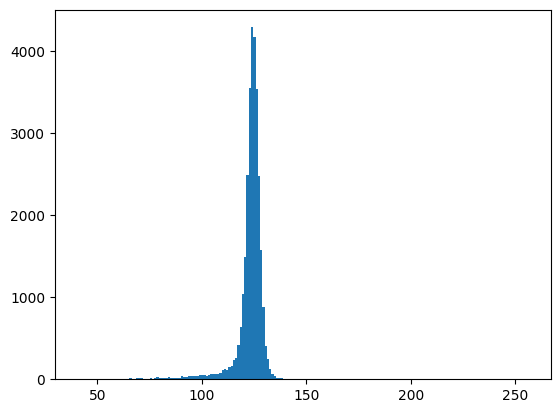

In [3]:
mass_hist_1 = simulated_higgs_signal["effective_mass"].hist(bin_count=200)
bin_width_1 = (mass_hist_1["breakpoint"][1:] - mass_hist_1["breakpoint"][:-1]).mean()
plt.bar(mass_hist_1["breakpoint"] - bin_width_1/2, mass_hist_1["count"],
        bin_width_1)
plt.show()

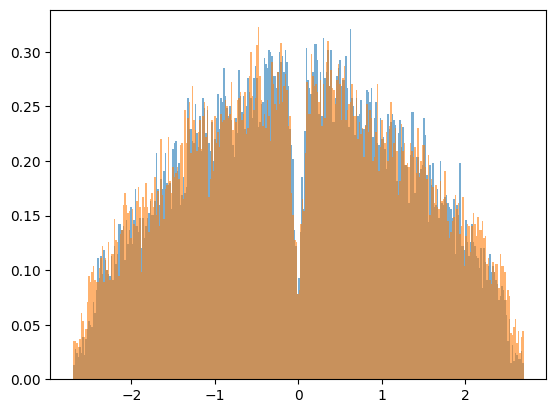

In [4]:
# plot pseudorapidity distribution
pseudoraidity_cut_hist_1 = simulated_higgs_signal["eta_1"].hist(bin_count=300)
bin_width_1 = (pseudoraidity_cut_hist_1["breakpoint"][1:] - pseudoraidity_cut_hist_1["breakpoint"][:-1]).mean()
density_1 = pseudoraidity_cut_hist_1["count"] / (pseudoraidity_cut_hist_1["count"].sum() * bin_width_1)
plt.bar(pseudoraidity_cut_hist_1["breakpoint"] - bin_width_1/2,
        density_1,
        bin_width_1, alpha=0.6)

pseudoraidity_cut_hist_2 = simulated_higgs_signal["eta_2"].hist(bin_count=300)
bin_width_2 = (pseudoraidity_cut_hist_2["breakpoint"][1:] - pseudoraidity_cut_hist_2["breakpoint"][:-1]).mean()
density_2 = pseudoraidity_cut_hist_2["count"] / (pseudoraidity_cut_hist_2["count"].sum() * bin_width_2)
plt.bar(pseudoraidity_cut_hist_2["breakpoint"] - bin_width_2/2,
        density_2,
        bin_width_2, alpha=0.6)
plt.show()

In [5]:
# make cuts - at least one muon has pseudorapidity of magnitude less than or equal to 2.1
print(simulated_higgs_signal.describe())
simulated_higgs_signal = simulated_higgs_signal.remove(
    (pl.col("eta_1").abs() >= 2.1) | (pl.col("eta_2").abs() >= 2.1)
)

print(simulated_higgs_signal.describe())

shape: (9, 8)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────────────┐
│ statistic  ┆ p_T1      ┆ phi_1     ┆ eta_1     ┆ p_T2      ┆ phi_2     ┆ eta_2     ┆ effective_m │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ass         │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ ---         │
│            ┆           ┆           ┆           ┆           ┆           ┆           ┆ f64         │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════════════╡
│ count      ┆ 30000.0   ┆ 30000.0   ┆ 30000.0   ┆ 30000.0   ┆ 30000.0   ┆ 30000.0   ┆ 30000.0     │
│ null_count ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0         │
│ mean       ┆ 72.94821  ┆ -0.009511 ┆ -0.006049 ┆ 45.532666 ┆ -0.008263 ┆ -0.009539 ┆ 122.743528  │
│ std        ┆ 31.725075 ┆ 1.811392  ┆ 1.262288  ┆ 14.913057 ┆ 1.811902  ┆ 1.

the count in the second table is lower than the count in the second table, so the cuts have actually been performed.

The maximum for `eta_1` and `eta_2` have changed from ~2.7 to ~2.1

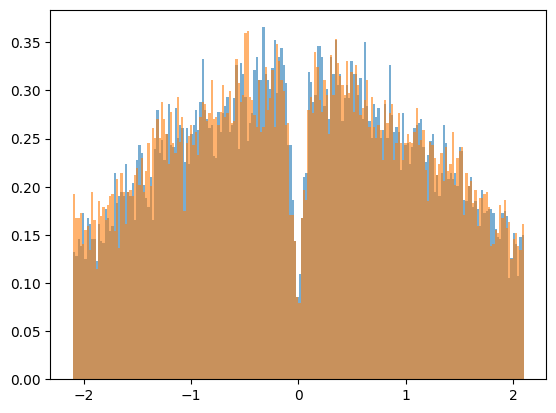

In [6]:
# plot distribution of pseudorapidity
pseudoraidity_cut_hist_1 = simulated_higgs_signal["eta_1"].hist(bin_count=200)
bin_width_1 = (pseudoraidity_cut_hist_1["breakpoint"][1:] - pseudoraidity_cut_hist_1["breakpoint"][:-1]).mean()
density_1 = pseudoraidity_cut_hist_1["count"] / (pseudoraidity_cut_hist_1["count"].sum() * bin_width_1)
plt.bar(pseudoraidity_cut_hist_1["breakpoint"] - bin_width_1/2, density_1,
        bin_width_1, alpha=0.6)

pseudoraidity_cut_hist_2 = simulated_higgs_signal["eta_2"].hist(bin_count=200)
bin_width_2 = (pseudoraidity_cut_hist_2["breakpoint"][1:] - pseudoraidity_cut_hist_2["breakpoint"][:-1]).mean()
density_2 = pseudoraidity_cut_hist_2["count"] / (pseudoraidity_cut_hist_1["count"].sum() * bin_width_2)
plt.bar(pseudoraidity_cut_hist_2["breakpoint"] - bin_width_2/2, density_2,
        bin_width_2, alpha=0.6)
plt.show()

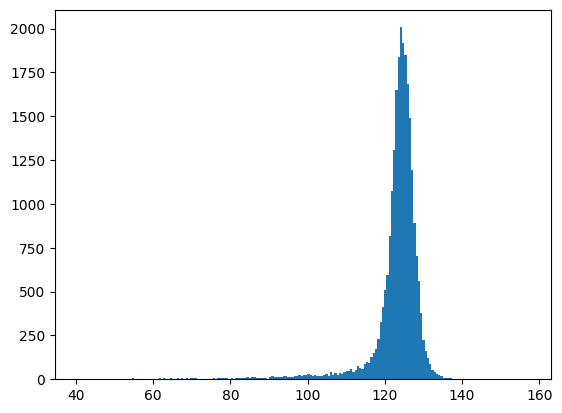

In [7]:
mass_hist = simulated_higgs_signal["effective_mass"].hist(bin_count=200)
bin_width_m = (mass_hist["breakpoint"][1:] - mass_hist["breakpoint"][:-1]).mean()


# frequency_normalised = np.array(mass_hist["count"] / (mass_hist["count"].sum() * bin_width_m))
frequency_of_mass_bins = np.array(mass_hist["count"])
centre_of_mass_bins = np.array(mass_hist["breakpoint"] - bin_width_m/2)
plt.bar(centre_of_mass_bins, frequency_of_mass_bins, bin_width_m)
plt.show()

# print(frequency_of_mass_bins.sum() * bin_width_m)
# print(frequency_of_mass_bins.sum())
# print(centre_of_mass_bins)

Try a double-sided Crystal Ball fit. It has a power law high and low mass tails and a gaussian core. Both the function and its derivative have to be continuous.

The function is defined below:

$$
\mathrm{DSCB}(m_{\mu\mu}; \hat m, \sigma, \alpha_L, n_L, \alpha_R, n_R) =
    \left\{
    \begin{array}{lr}
         A_L \cdot (B_L - \dfrac{m_{\mu\mu} - \hat m}{\sigma}), & -\alpha_L < \frac{m_{\mu\mu} - \hat m}{\sigma} \\
         \exp\left( \dfrac{1}{2} \left( \dfrac{m_{\mu\mu} - \hat m}{\sigma} \right)^2 \right),
         & -\alpha_L \leq \frac{m_{\mu\mu} - \hat m}{\sigma} \leq \alpha_R \\
         A_R \cdot (B_R + \dfrac{m_{\mu\mu} - \hat m}{\sigma}), & -\alpha_R < \frac{m_{\mu\mu} - \hat m}{\sigma} \\
    \end{array}
    \right.
$$

$$
\begin{array}{l}
    A_{L/R} =
        \left( \dfrac{n_{L/R}}{|\alpha_{L/R}|} \right)^{n_{L/R}}
        \cdot \exp \left( -\dfrac{(\alpha_{L/R})^2}{2} \right), \\
    B_{L/R} = \dfrac{n_{L/R}}{|\alpha_{L/R}|} - |\alpha_{L/R}|\\
\end{array}
$$

Where $m_{\mu \mu}$ is the mass of the dimuon system and $\hat m, \sigma, \alpha_L, n_L, \alpha_R, n_R$ are all fitting parameters. $\hat m$ then represents the mass of the Higgs Boson.

I have coded in an extra parameter. It is simply a constant that multiplies everything

In [8]:
# define double-sided Crystal Ball fit
# the function was coded without if statements to make it compatible with arrays.
def DSCB(m, m_hat, sigma, alpha_l, n_l, alpha_r, n_r, const):
    result = 0
    # logarithms were used so that high values could be easily dealt with

    # low mass tail
    condition_low_mass_tail = ((m-m_hat)/sigma <= -alpha_l)
    low_mass_tail = np.exp(
            n_l*np.log(n_l/np.abs(alpha_l))  - (alpha_l**2 / 2)
            -n_l*np.log(n_l/np.abs(alpha_l) - np.abs(alpha_l) - (m - m_hat)/sigma)
    ) * condition_low_mass_tail

    # gaussian
    condition_gaussian = (-alpha_l < (m-m_hat)/sigma) & ((m-m_hat)/sigma < alpha_r)
    gaussian_core = np.exp(- (m - m_hat)**2 / (2 * sigma**2)) * condition_gaussian

    # high mass tail
    condition_high_mass_tail = ((m-m_hat)/sigma >= alpha_r)
    # logarithms were used so high values could be easily dealt with.
    high_mass_tail = np.exp(
        n_r*np.log(n_r / np.abs(alpha_r)) - (alpha_r**2/2)
        - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)
    ) * condition_high_mass_tail

    return const * (low_mass_tail + gaussian_core + high_mass_tail)

m_hat = 124.5959420548526,
sigma = 2.485040762809865,
alpha_l = 1.0276431952220901,
n_l = 725164.8051923094
alpha_r = 1.3998972380834207,
n_l = 4002657.00318281,
const = 1347.8316443364863


C:\Users\karth\AppData\Local\Temp\ipykernel_18684\2860227239.py:22: RuntimeWarning: invalid value encountered in log
  n_r*np.log(n_r / np.abs(alpha_r)) - (alpha_r**2/2)
C:\Users\karth\AppData\Local\Temp\ipykernel_18684\2860227239.py:23: RuntimeWarning: invalid value encountered in log
  - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)


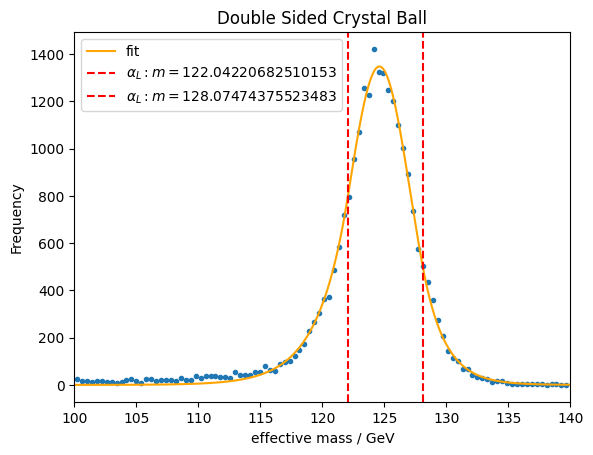

In [9]:
# restrict range
lower_bound = 100
upper_bound = 140
simulated_higgs_signal_restricted = simulated_higgs_signal.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

# plot histogram of data
mass_hist = simulated_higgs_signal_restricted["effective_mass"].hist(bin_count=100)
bin_width_m = (mass_hist["breakpoint"][1:] - mass_hist["breakpoint"][:-1]).mean()

# frequency_normalised = np.array(mass_hist["count"] / (mass_hist["count"].sum() * bin_width_m))
frequency_of_mass_bins = np.array(mass_hist["count"])
# print(frequency_of_mass_bins)
centre_of_mass_bins = np.array(mass_hist["breakpoint"] - bin_width_m/2)
# plt.bar(centre_of_mass_bins, frequency_of_mass_bins, bin_width_m)
plt.scatter(centre_of_mass_bins, frequency_of_mass_bins, marker=".")


# plot model
masses = np.linspace(lower_bound, upper_bound, 1000)

# try fit all parameters at once
popt, pcov = optimize.curve_fit(
    DSCB, centre_of_mass_bins, frequency_of_mass_bins, p0=[125, 3, 2, 1000000, 4, 1000000, 1500],
    maxfev=1000000
)

print(f"m_hat = {popt[0]},\nsigma = {popt[1]},\nalpha_l = {popt[2]},\nn_l = {popt[3]}"
      f"\nalpha_r = {popt[4]},\nn_l = {popt[5]},\nconst = {popt[6]}")
fit_values = DSCB(masses, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5], popt[6])

plt.plot(masses, fit_values, label="fit", color="orange")

# plot boundaries where the power law and core gaussian are
plt.axvline(-popt[2] * popt[1] + popt[0], label=f"$\\alpha_L: m = {-popt[2] * popt[1] + popt[0]}$",
            color="red", linestyle="--")
plt.axvline(popt[4] * popt[1] + popt[0], label=f"$\\alpha_L: m = {popt[4] * popt[1] + popt[0]}$",
            color="red", linestyle="--")

plt.xlim(lower_bound, upper_bound)
plt.xlabel("effective mass / GeV")
plt.ylabel("Frequency")
plt.title("Double Sided Crystal Ball")
plt.legend()
plt.show()

# print(pcov)
# print(frequency_of_mass_bins.sum() * bin_width_m)
# print(frequency_of_mass_bins)
# print(centre_of_mass_bins)

Now, try to interpret the covariance matrix

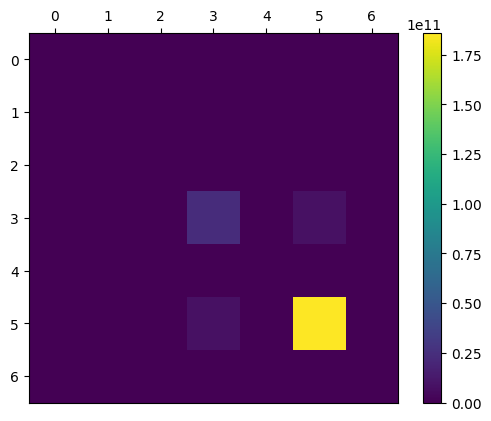

err_m_hat = 0.018198%,
err_sigma = 1.263208%,
err_alpha_L = 3.225650%,
err_n_L = 21.252962%,
err_alpha_R = 5.291268%,
err_n_R = 10.771334%,
err_const = 0.688744%,



In [10]:
plt.imshow(pcov)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

# display(pcov)
# display(pcov / popt)

print(f"err_m_hat = {np.sqrt(pcov[0,0]) / popt[0]:%},\n"
      f"err_sigma = {np.sqrt(pcov[1,1]) / popt[1]:%},\n"
      f"err_alpha_L = {np.sqrt(pcov[2,2]) / popt[2]:%},\n"
      f"err_n_L = {np.sqrt(pcov[3,3]) / popt[3]:%},\n"
      f"err_alpha_R = {np.sqrt(pcov[4,4]) / popt[4]:%},\n"
      f"err_n_R = {np.sqrt(pcov[5,5]) / popt[5]:%},\n"
      f"err_const = {np.sqrt(pcov[6,6]) / popt[6]:%},\n"
      )

These are the best values I have got.
With these starting values:\
m_hat = 125, sigma = 3, alpha_l = 2, n_l = 1000000, alpha_r = 4, n_r = 1000000, const = 1500

m_hat = 124.5959420548526,\
sigma = 2.485040762809865,\
alpha_l = 1.0276431952220901,\
n_l = 725164.8051923094,\
alpha_r = 1.3998972380834207,\
n_R = 4002657.00318281,\
const = 1347.8316443364863,
\
\
err_m_hat = 0.018198%,\
err_sigma = 1.263208%,\
err_alpha_L = 3.225650%,\
err_n_L = 21.252962%,\
err_alpha_R = 5.291268%,\
err_n_R = 10.771334%,\
err_const = 0.688744%,

Above is a chart visualising the covariance matrix. The diagram shows that `popt[3]` and `popt[5]` have the highest error, which corresponds to $n_l$ and $n_r$
\
Whatever starting values that are put in, there seems to be a trade-off in accuracy between ending values of n_L and n_R
\
Attempt to replace the low tail with exponential to see if get a better fit

Equation used for low mass tail, derived from boundary conditions of both the function and its derivative being continuous:
\
$\exp\left(\frac{\alpha_L^2}{2} \right) \exp \left( -\alpha_L \frac{m - \hat m}{\sigma} \right)$

In [11]:
def DSCBexponential(m, m_hat, sigma, alpha_l, alpha_r, n_r, const):
    result = 0
    # low mass tail
    condition_low_mass_tail = ((m-m_hat)/sigma <= -alpha_l)
    # print("lm", condition_low_mass_tail)
    low_mass_tail = np.exp(
        alpha_l**2/2 + alpha_l*(m - m_hat)/sigma
    ) * condition_low_mass_tail
    # low_mass_tail = ((n_l/np.abs(alpha_l))**n_l *
    #           np.exp(-(alpha_l**2)/2) *
    #           (n_l / np.abs(alpha_l) - np.abs(alpha_l) - (m - m_hat)/sigma))**-n_l * condition_low_mass_tail

    # gaussian
    condition_gaussian = (-alpha_l < (m-m_hat)/sigma) & ((m-m_hat)/sigma < alpha_r)
    # print("g", condition_gaussian)
    gaussian_core = np.exp(- (m - m_hat)**2 / (2 * sigma**2)) * condition_gaussian

    # high mass tail
    condition_high_mass_tail = ((m-m_hat)/sigma >= alpha_r)
    # print("hm", condition_high_mass_tail)
    high_mass_tail = np.exp(
        n_r*np.log(n_r / np.abs(alpha_r)) - (alpha_r**2/2)
        - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)
    ) * condition_high_mass_tail
    # high_mass_tail = (
    #      (n_r/np.abs(alpha_r))**n_r *
    #      np.exp(-(alpha_r**2)/2) *
    #      (n_r / np.abs(alpha_r) - np.abs(alpha_r) - (m - m_hat)/sigma)**-n_r * condition_high_mass_tail
    # )
    return const * (low_mass_tail + gaussian_core + high_mass_tail)

mass of higgs = 124.59515323340811,
sigma = 2.4783218014099306,
alpha_l = 1.025214671352431,
alpha_r = 1.363814546977853,
n_l = 100281.5133918658,
const = 1348.222149206602


C:\Users\karth\AppData\Local\Temp\ipykernel_18684\20310897.py:6: RuntimeWarning: overflow encountered in exp
  low_mass_tail = np.exp(
C:\Users\karth\AppData\Local\Temp\ipykernel_18684\20310897.py:23: RuntimeWarning: invalid value encountered in log
  - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)
C:\Users\karth\AppData\Local\Temp\ipykernel_18684\20310897.py:21: RuntimeWarning: overflow encountered in exp
  high_mass_tail = np.exp(


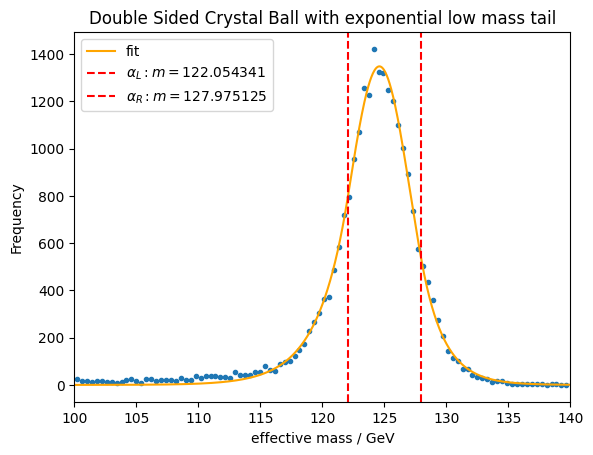

[[ 4.42613078e-04 -1.30738986e-04 -2.82709174e-04  1.78731803e-04
   1.02690386e+03  2.06449030e-02]
 [-1.30738986e-04  8.95298453e-04  6.74661496e-04  1.22937195e-03
   2.97538365e+03 -1.84250986e-01]
 [-2.82709174e-04  6.74661496e-04  1.16932654e-03  8.12830183e-04
   1.77886436e+03 -9.98201631e-02]
 [ 1.78731803e-04  1.22937195e-03  8.12830183e-04  6.03894215e-03
   3.71093568e+04 -2.02708052e-01]
 [ 1.02690386e+03  2.97538365e+03  1.77886436e+03  3.71093568e+04
   1.05398164e+12 -4.07124940e+05]
 [ 2.06449030e-02 -1.84250986e-01 -9.98201631e-02 -2.02708052e-01
  -4.07124940e+05  8.57983174e+01]]


In [12]:
# first, try to fit all parameters at once
popt2, pcov2 = optimize.curve_fit(
    DSCBexponential, centre_of_mass_bins, frequency_of_mass_bins, p0=[125, 7, 5, 5, 100000, 2000],
    maxfev=10000000
)

# restrict range
lower_bound = 100
upper_bound = 140
simulated_higgs_signal_restricted = simulated_higgs_signal.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

# plot histogram of data
mass_hist = simulated_higgs_signal_restricted["effective_mass"].hist(bin_count=100)
bin_width_m = (mass_hist["breakpoint"][1:] - mass_hist["breakpoint"][:-1]).mean()

# frequency_normalised = np.array(mass_hist["count"] / (mass_hist["count"].sum() * bin_width_m))
frequency_of_mass_bins = np.array(mass_hist["count"])
# print(frequency_of_mass_bins)
centre_of_mass_bins = np.array(mass_hist["breakpoint"] - bin_width_m/2)
# plt.bar(centre_of_mass_bins, frequency_of_mass_bins, bin_width_m)
plt.scatter(centre_of_mass_bins, frequency_of_mass_bins, marker=".")


# plot model
masses = np.linspace(lower_bound, upper_bound, 1000)
print(f"mass of higgs = {popt2[0]},\nsigma = {popt2[1]},\nalpha_l = {popt2[2]},"
      f"\nalpha_r = {popt2[3]},\nn_l = {popt2[4]},\nconst = {popt2[5]}")
fit_values_1 = DSCBexponential(masses, popt2[0], popt2[1], popt2[2], popt2[3], popt2[4], popt2[5])

plt.plot(masses, fit_values_1, label="fit", color="orange")

# plot boundaries where the power law and ccb
plt.axvline(-popt2[2] * popt2[1] + popt2[0], label=f"$\\alpha_L: m = {-popt2[2] * popt2[1] + popt2[0]:.9}$",
            color="red", linestyle="--")
plt.axvline(popt2[3] * popt2[1] + popt2[0], label=f"$\\alpha_R: m = {popt2[3] * popt2[1] + popt2[0]:.9}$",
            color="red", linestyle="--")
# plt.plot(masses, fit_values_2, label="made up", color="red")
plt.xlim(lower_bound, upper_bound)
plt.title("Double Sided Crystal Ball with exponential low mass tail")
plt.xlabel("effective mass / GeV")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(pcov2)
# print(frequency_of_mass_bins.sum() * bin_width_m)
# print(frequency_of_mass_bins)
# print(centre_of_mass_bins)

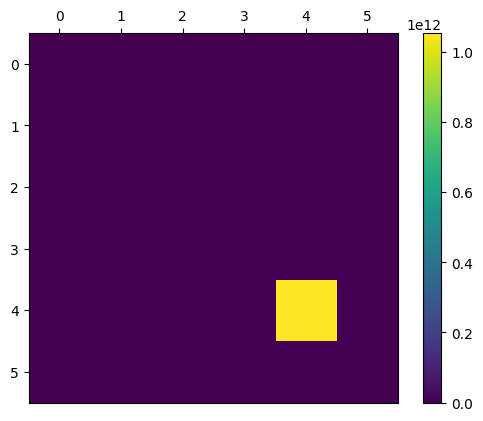

err_m_hat = 0.016885%,
err_sigma = 1.207331%,
err_alpha_L = 3.335440%,
err_alpha_R = 5.698035%,
err_n_R = 1023.754075%,
err_const = 0.687034%,



In [13]:
plt.imshow(pcov2)
plt.colorbar()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.show()

# display(pcov2)
# display(pcov2 / popt2)

print(f"err_m_hat = {np.sqrt(pcov2[0,0]) / popt2[0]:%},\n"
      f"err_sigma = {np.sqrt(pcov2[1,1]) / popt2[1]:%},\n"
      f"err_alpha_L = {np.sqrt(pcov2[2,2]) / popt2[2]:%},\n"
      f"err_alpha_R = {np.sqrt(pcov2[3,3]) / popt2[3]:%},\n"
      f"err_n_R = {np.sqrt(pcov2[4,4]) / popt2[4]:%},\n"
      f"err_const = {np.sqrt(pcov2[5,5]) / popt2[5]:%},\n"
      )

Power Law low mass tail seems to fit better. Keep that one.